## Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import psycopg2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

## Load Dataset

In [2]:
# PostgreSQL Connection
conn = psycopg2.connect(
    host="localhost",
    database="internprojects",   
    user="postgres",       
    password="2526", 
    port="5432"
)

In [3]:
cur = conn.cursor()


# Table names fetch
cur.execute("""
    SELECT table_name 
    FROM information_schema.tables
    WHERE table_schema = 'public';
""")

tables = cur.fetchall()

# Print table names
print("Tables in database:")
for table in tables:
    print(table[0])

Tables in database:
supermart_grocery_sales


In [4]:
data = pd.read_sql('SELECT * FROM "supermart_grocery_sales";', conn)
# Display the first few rows of the dataset
data.head()

,order_id,customer_name,category,sub_category,city,order_date,region,sales,discount,profit,state
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


## Data Preprocessing

In [5]:
data.shape

(9994, 11)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   customer_name  9994 non-null   object 
 2   category       9994 non-null   object 
 3   sub_category   9994 non-null   object 
 4   city           9994 non-null   object 
 5   order_date     9994 non-null   object 
 6   region         9994 non-null   object 
 7   sales          9994 non-null   int64  
 8   discount       9994 non-null   float64
 9   profit         9994 non-null   float64
 10  state          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


* 1. Check for Missing Values and Handle Them

In [7]:
# Check for missing values
data.isnull().sum()

order_id         0
customer_name    0
category         0
sub_category     0
city             0
order_date       0
region           0
sales            0
discount         0
profit           0
state            0
dtype: int64

In [8]:
# Remove duplicates
data.drop_duplicates(inplace=True)

* 2. Convert Date Columns to DateTime Format

In [9]:
data['order_date']

0       11-08-2017
1       11-08-2017
2       06-12-2017
3       10-11-2016
4       10-11-2016
           ...    
9989    12/24/2015
9990    07-12-2015
9991    06-06-2017
9992    10/16/2018
9993     4/17/2018
Name: order_date, Length: 9994, dtype: object

In [10]:
# Convert order_date column to datetime by handling mixed date formats.
data['order_date'] = pd.to_datetime(
    data['order_date'],
    format='mixed',
    dayfirst=True
)

In [11]:
data['order_date']

0      2017-08-11
1      2017-08-11
2      2017-12-06
3      2016-11-10
4      2016-11-10
          ...    
9989   2015-12-24
9990   2015-12-07
9991   2017-06-06
9992   2018-10-16
9993   2018-04-17
Name: order_date, Length: 9994, dtype: datetime64[ns]

In [12]:
# Extract day, month, and year from 'Order Date'
data['order_day'] = data['order_date'].dt.day
data['order_month'] = data['order_date'].dt.month
data['order_year'] = data['order_date'].dt.year

In [13]:
data.head(3)

,order_id,customer_name,category,sub_category,city,order_date,region,sales,discount,profit,state,order_day,order_month,order_year
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,11,8,2017
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,11,8,2017
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,6,12,2017


## Exploratory Data Analysis (EDA)

In [14]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
order_date,9994,2017-04-11 12:33:42.973784064,2015-01-02 00:00:00,2016-05-01 00:00:00,2017-05-30 00:00:00,2018-04-09 00:00:00,2018-12-30 00:00:00,NaN
sales,9994.0,1496.596158,500.0,1000.0,1498.0,1994.75,2500.0,577.559036
discount,9994.0,0.226817,0.1,0.16,0.23,0.29,0.35,0.074636
profit,9994.0,374.937082,25.25,180.0225,320.78,525.6275,1120.95,239.932881
order_day,9994.0,16.103462,1.0,10.0,15.0,23.0,31.0,8.064182
order_month,9994.0,7.174605,1.0,4.0,8.0,10.0,12.0,3.428273
order_year,9994.0,2016.722233,2015.0,2016.0,2017.0,2018.0,2018.0,1.123555


In [15]:
# applying groupby() function to group the data on Category.
df = data.groupby("category")
df.first()

,order_id,customer_name,sub_category,city,order_date,region,sales,discount,profit,state,order_day,order_month,order_year
category,,,,,,,,,,,,,
Bakery,OD9,Hafiz,Biscuits,Tirunelveli,2015-09-06,West,791,0.23,181.93,Tamil Nadu,6,9,2015
Beverages,OD2,Sudha,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,11,8,2017
"Eggs, Meat & Fish",OD12,Yadav,Eggs,Namakkal,2015-09-06,West,701,0.10,308.44,Tamil Nadu,6,9,2015
Food Grains,OD3,Hussain,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,6,12,2017
Fruits & Veggies,OD4,Jackson,Fresh Vegetables,Dharmapuri,2016-11-10,South,896,0.25,89.60,Tamil Nadu,10,11,2016
Oil & Masala,OD1,Harish,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,11,8,2017
Snacks,OD11,Ganesh,Chocolates,Karur,2015-09-06,West,1903,0.13,437.69,Tamil Nadu,6,9,2015


In [16]:
# We want to find the total sale by category firstly, we group by Category and get the total number of sales for each category
Sales_category = data.groupby("category")["sales"].sum()

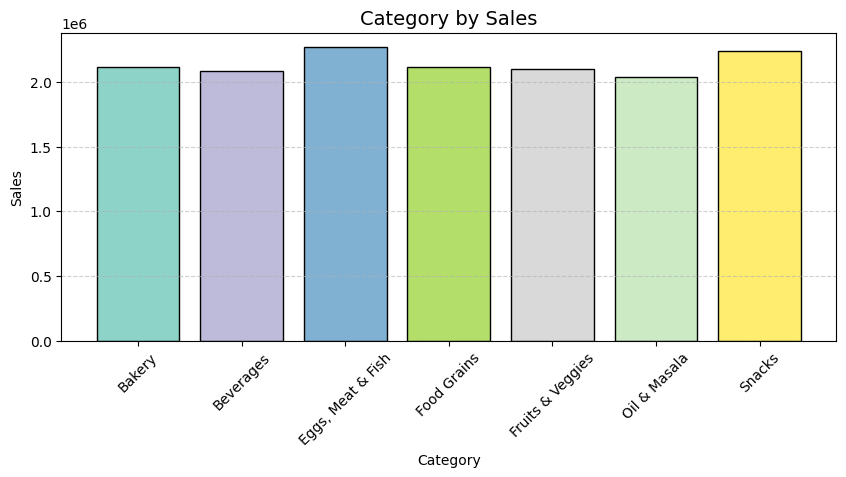

In [17]:
colors = plt.cm.Set3(np.linspace(0, 1, len(Sales_category)))

plt.figure(figsize=(10,4))
plt.bar(
    Sales_category.index,
    Sales_category.values,
    color=colors,
    edgecolor='black'
)
plt.title('Category by Sales', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

-- The Egg, Meat &Fish Category contribute most to the sales, it had about 15% of
the total sales, the company can invest more in it.

In [18]:
#Extract month from the order date
data['month'] = pd.to_datetime(data['order_date']).dt.strftime('%B')
data.head(3)

,order_id,customer_name,category,sub_category,city,order_date,region,sales,discount,profit,state,order_day,order_month,order_year,month
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,11,8,2017,August
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,11,8,2017,August
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,6,12,2017,December


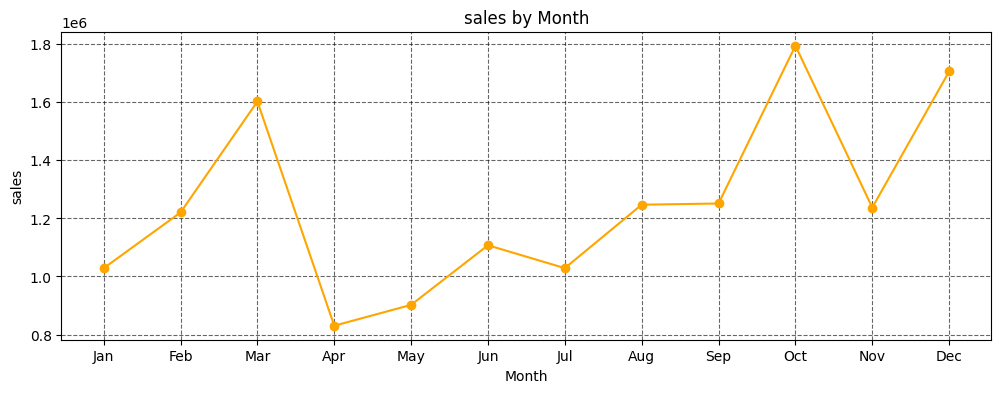

In [19]:
# Sum up sales by month
monthly_sales = data.groupby('month')['sales'].sum().reset_index()

# Sort the data by month
monthly_sales_sorted = monthly_sales.sort_values(by='month')

# Create the line chart
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales_sorted['month'],
monthly_sales_sorted['sales'], marker='o', color = "orange")
plt.title('sales by Month')
plt.xlabel('Month')
plt.ylabel('sales')
plt.xticks(monthly_sales_sorted['month'], ['Jan', 'Feb', 'Mar',
'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True ,linestyle='--', alpha=0.6,color = "black")
plt.show()

-- The Sales increase as the month increases which shows the company devised
better and suitable plan to increase sales at each point in time.

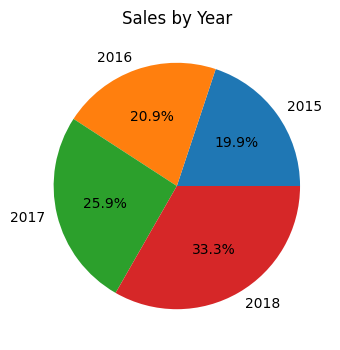

In [20]:
plt.figure(figsize=(4,4))
# we group by Year and get the total number of sales for each year
Yearly_Sales = data.groupby("order_year")["sales"].sum()

# we create a pie chart with the sales by year
plt.pie(Yearly_Sales, labels = Yearly_Sales.index,
autopct='%1.1f%%')
plt.title('Sales by Year')
plt.show()

-- The year 2017 and 2018 had more than 50 percent of the total sales which
implies the sales increase as the year increases.

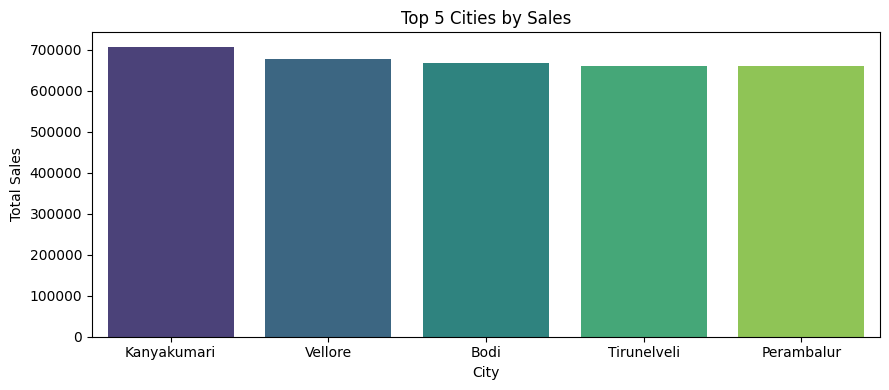

In [21]:
top_cities = (data.groupby('city')['sales'].sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(9,4))
sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')

plt.title('Top 5 Cities by Sales')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

 * 1. Distribution of Sales by Category

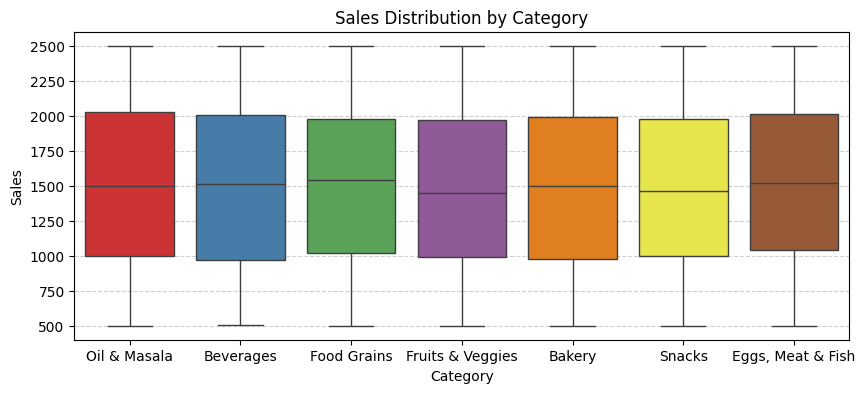

In [22]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='category', y='sales', data=data, palette='Set1')
plt.title('Sales Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

. The graph shows how sales are spread across different categories.

. Sales are almost similar in all categories, with no big difference between them.

. This means no single category has much higher or lower sales than the others.

* 2. Sales Trends Over Time

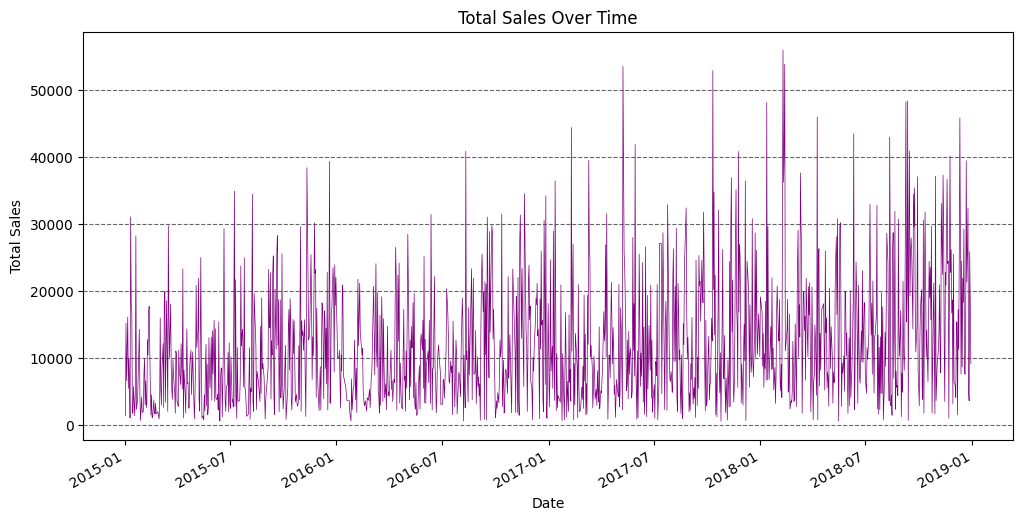

In [23]:
plt.figure(figsize=(12, 6))
data_group = data.groupby('order_date')['sales'].sum().plot(color = 'purple' , linewidth = 0.5)
plt.grid(axis='y', linestyle='--', alpha=0.6,color = "black")
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

* The graph shows total sales over time from 2015 to 2019.
* Sales are lowest in 2015, increase gradually during 2016–2017, and reach their highest levels in 2018.
* Overall, 2016–2017 show average sales, while 2018 records the highest sales across the period.

* 3. Correlation Heatmap

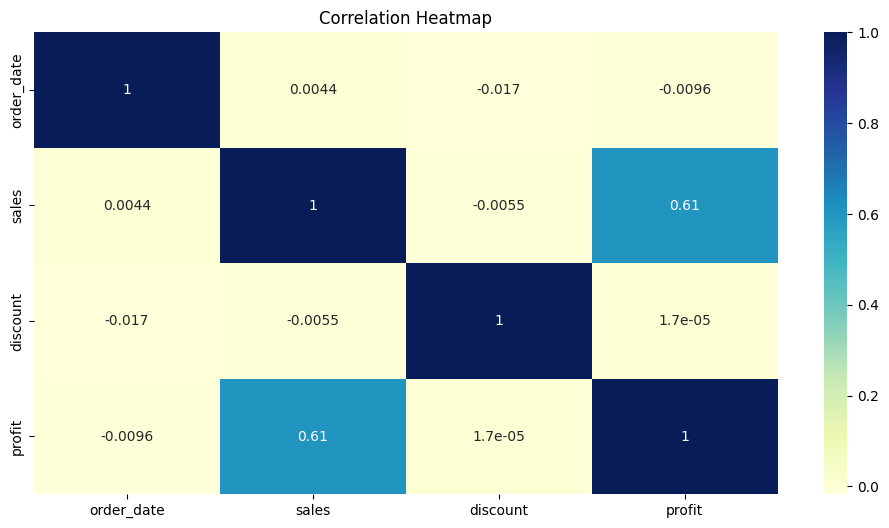

In [24]:
numeric_col = data.select_dtypes(include=['int64','float64','datetime64'])

plt.figure(figsize=(12, 6))
sns.heatmap(numeric_col.corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

-- The heatmap shows relationships between variables.

-- Sales and profit have the strongest correlation (≈ 0.61).

-- All other variables show weak or near-zero correlation.

## Feature Selection

In [25]:
data.head(3)

,order_id,customer_name,category,sub_category,city,order_date,region,sales,discount,profit,state,order_day,order_month,order_year,month
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,11,8,2017,August
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,11,8,2017,August
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,6,12,2017,December


In [26]:
# Remove unwanted features
data = data.drop(columns=['order_id', 'customer_name', 'order_date', 'month'])
data.head(3)

,category,sub_category,city,region,sales,discount,profit,state,order_day,order_month,order_year
0,Oil & Masala,Masalas,Vellore,North,1254,0.12,401.28,Tamil Nadu,11,8,2017
1,Beverages,Health Drinks,Krishnagiri,South,749,0.18,149.80,Tamil Nadu,11,8,2017
2,Food Grains,Atta & Flour,Perambalur,West,2360,0.21,165.20,Tamil Nadu,6,12,2017


## Label Encoding for Categorical Variables

In [27]:
# Initialize the label encoder
le = LabelEncoder()

In [28]:
# Encode categorical variables
data['category'] = le.fit_transform(data['category'])
data['sub_category'] = le.fit_transform(data['sub_category'])
data['city'] = le.fit_transform(data['city'])
data['region'] = le.fit_transform(data['region'])
data['state'] = le.fit_transform(data['state'])

In [29]:
data.head(3)

,category,sub_category,city,region,sales,discount,profit,state,order_day,order_month,order_year
0,5,14,21,2,1254,0.12,401.28,0,11,8,2017
1,1,13,8,3,749,0.18,149.80,0,11,8,2017
2,3,0,13,4,2360,0.21,165.20,0,6,12,2017


## Feature scaling

In [30]:
X = data.drop(columns=['sales'])
y = data['sales']

In [31]:
sc = StandardScaler()
sc.fit_transform(X)

X = pd.DataFrame(sc.fit_transform(X), columns=X.columns)
X.head(4)

,category,sub_category,city,region,discount,profit,state,order_day,order_month,order_year
0,0.988438,0.435711,1.380810,-0.032603,-1.431246,0.109798,0.0,-0.632887,0.240773,0.247234
1,-1.003687,0.285938,-0.494753,0.581013,-0.627304,-0.938381,0.0,-0.632887,0.240773,0.247234
2,-0.007624,-1.661110,0.226617,1.194629,-0.225333,-0.874193,0.0,-1.252944,1.407600,0.247234
3,0.490407,0.136165,-1.071849,0.581013,0.310629,-1.189297,0.0,-0.756899,1.115893,-0.642843


## Train Test Split

In [32]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=52)

## Model Apply

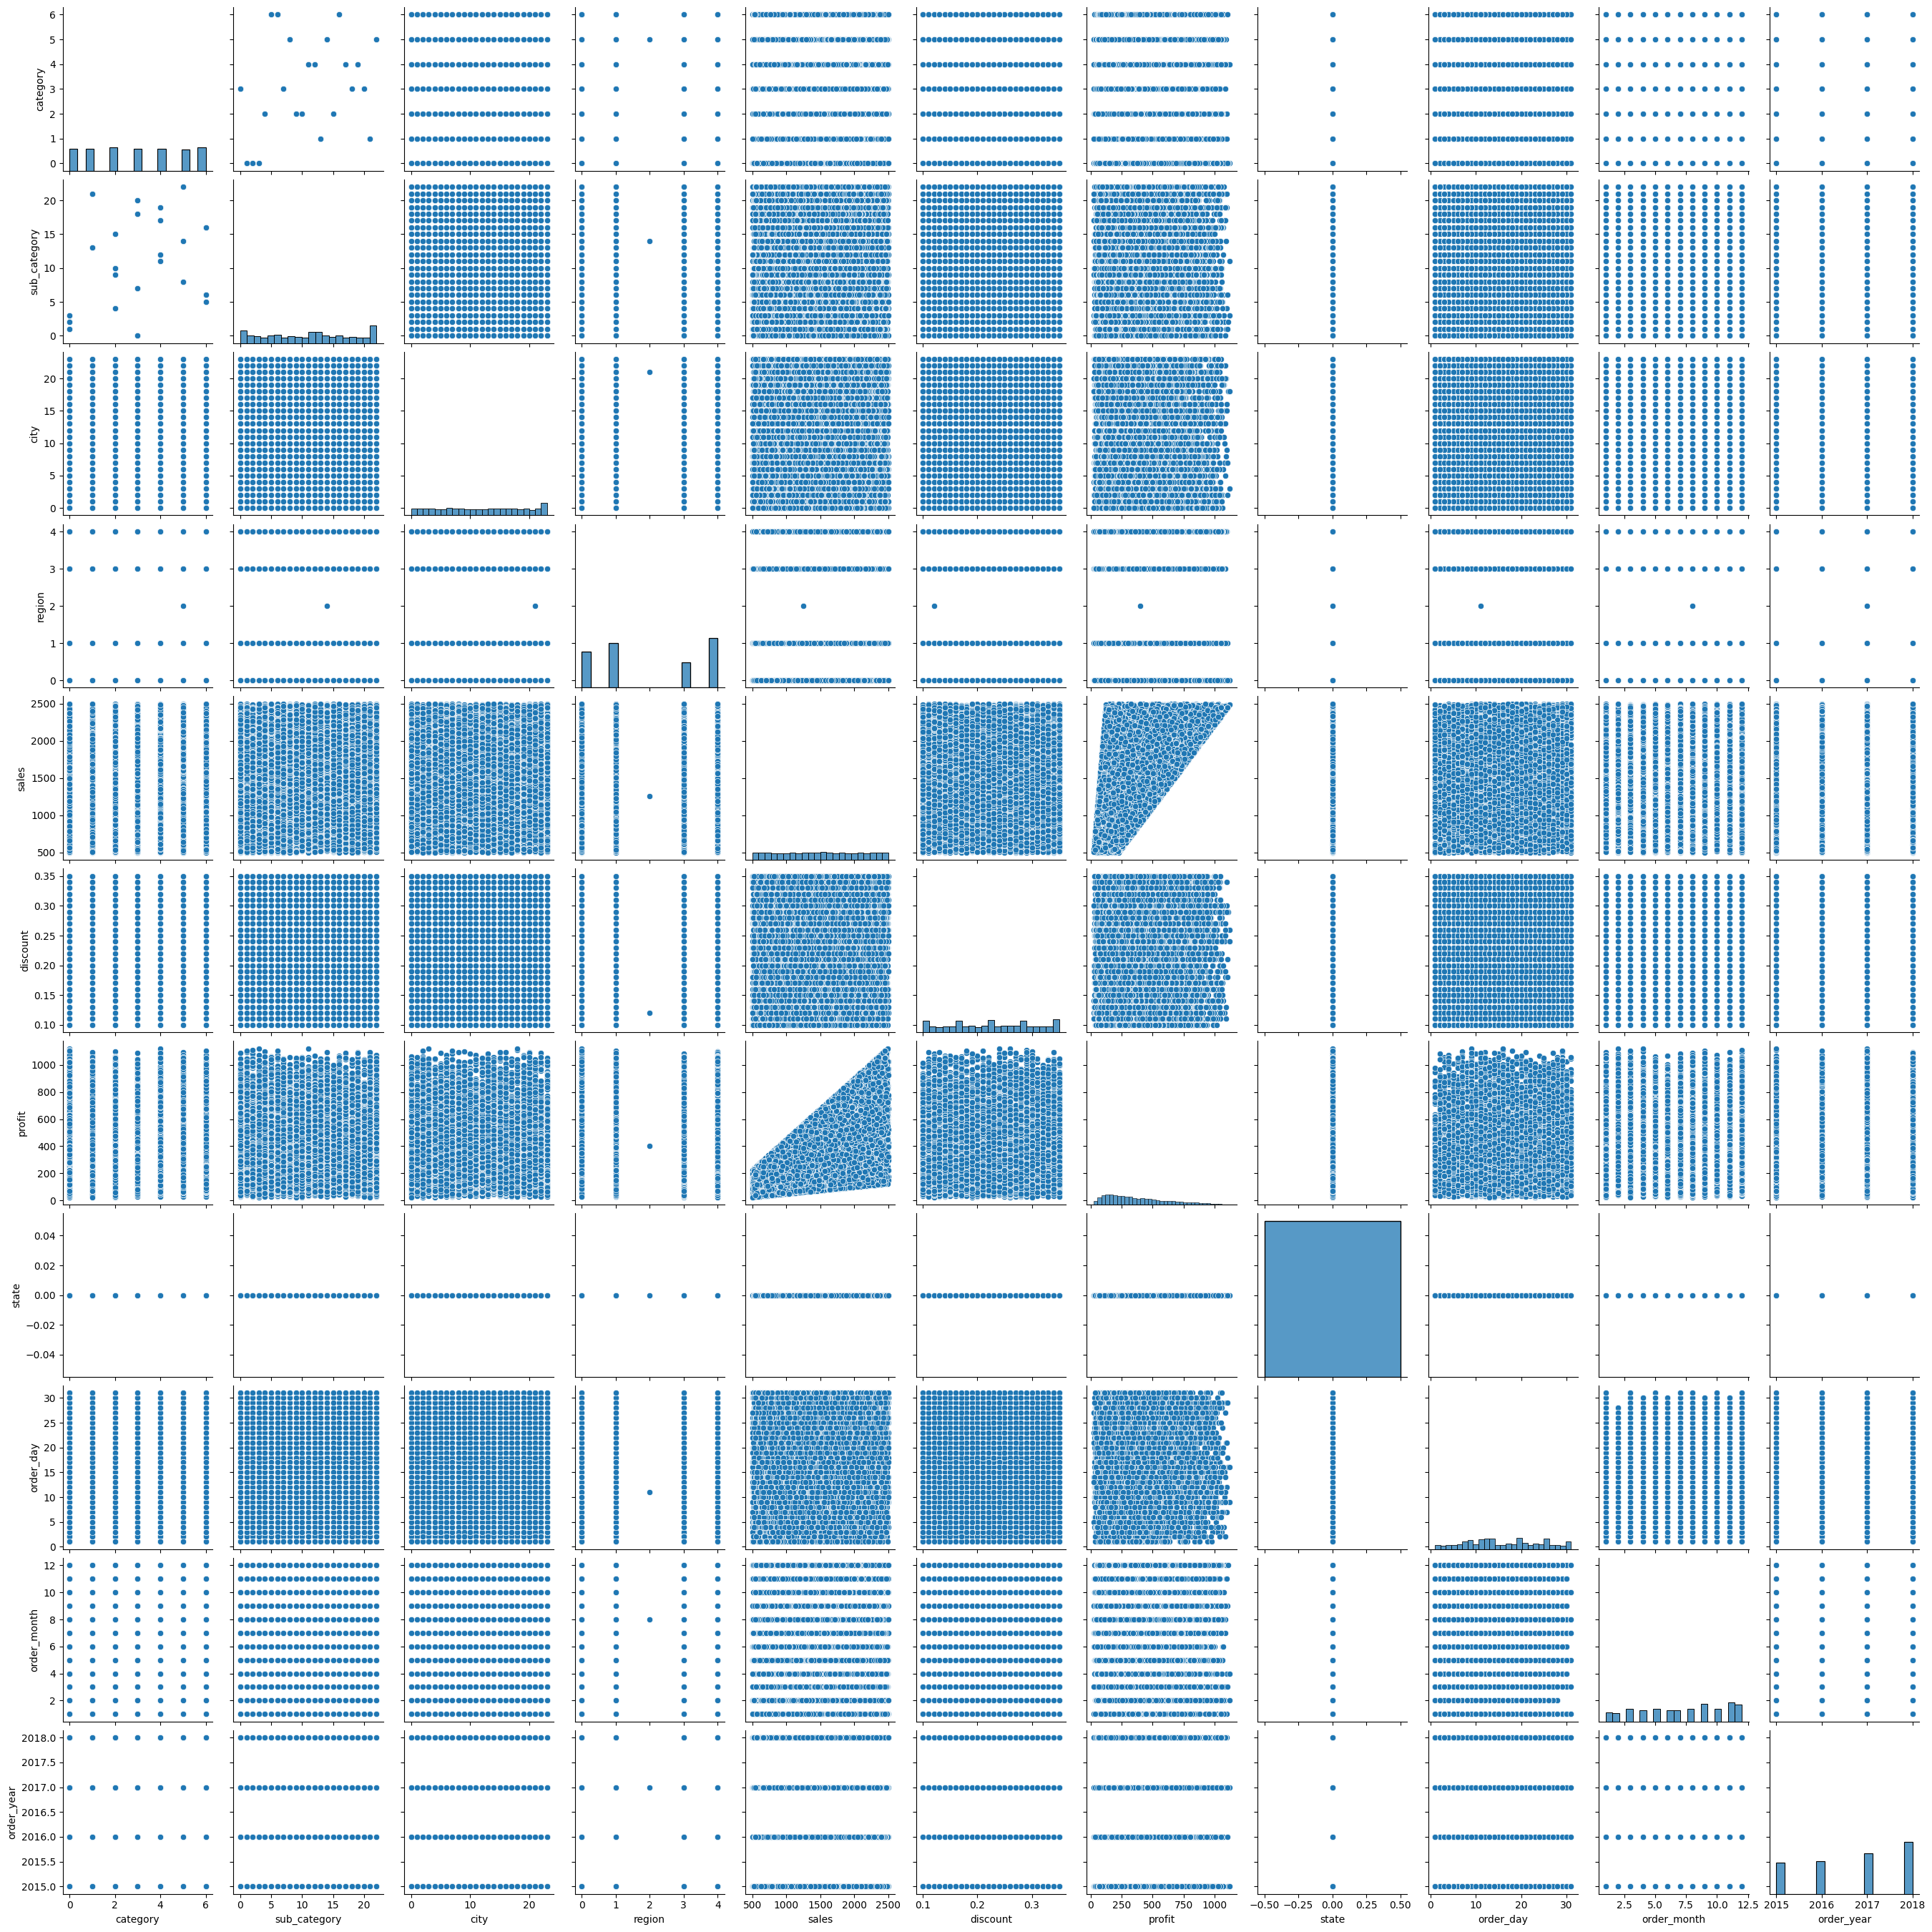

In [33]:
# lets see the behaviour of the data
sns.pairplot(data)
plt.show()

In [34]:
# XGBRegressor
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb.score(X_test, y_test)*100 , xgb.score(X_train, y_train)*100

(33.3551824092865, 67.73349046707153)

In [35]:
# Linear Regression 
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)*100 , lr.score(X_train, y_train)*100

(36.29445995904741, 36.695670834787705)

In [36]:
# DecisionTreeClassifier 
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor( max_depth=5)
dt.fit(X_train,y_train)
dt.score(X_test,y_test)*100 , dt.score(X_train,y_train)*100

(36.88913452723362, 38.909475669130835)

In [37]:
# Support Vector Machine
from sklearn.svm import SVR
sv = SVR(kernel='sigmoid')
sv.fit(X_train, y_train)
sv.score(X_test, y_test)*100 , sv.score(X_train, y_train)*100

(31.93135556988298, 32.68223657119241)

In [38]:
# KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train, y_train)
knn.score(X_test, y_test)*100 , knn.score(X_train, y_train)*100

(23.72847727368169, 39.95962763001499)

In [39]:
# RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=6)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)*100 , rf.score(X_train, y_train)*100

(26.084664441219385, 84.8637152249685)

In [40]:
# LogisticRegression
from sklearn.linear_model import LogisticRegression
lo = LogisticRegression()
lo.fit(X_train, y_train)
lo.score(X_test, y_test)*100 , rf.score(X_train, y_train)*100

(0.0, 84.8637152249685)

In [41]:
# for i in range(1,30):
#     rf = RandomForestRegressor(n_estimators=6)
#     rf.fit(X_train, y_train)
#     print(i,rf.score(X_test, y_test)*100 , rf.score(X_train, y_train)*100)

In [42]:
# Make predictions Linear Model
y_pred = lr.predict(X_test)

## Evaluate the Model

In [43]:
# Calculate MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [44]:
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 217563.8101036828
R-squared: 0.3629445995904741


## Visualize the Results

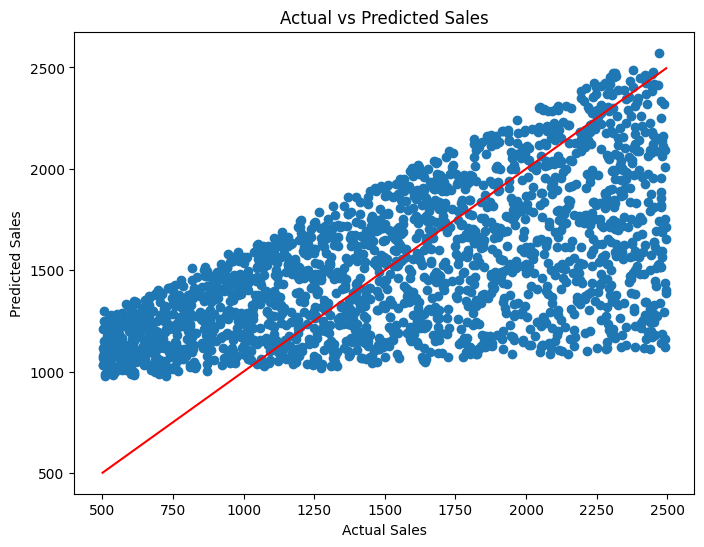

In [45]:
#  Actual vs Predicted Sales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test),
max(y_test)],
[min(y_test),
max(y_test)], color='red')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

## `Conclusion`

In this project, I performed feature selection and experimented with multiple machine learning algorithms including `XGBRegressor`, `Decision Tree Regressor`, `Random Forest Regressor`, `SVR`, `KNN`, `Logistic Regression`, and `Linear Regression` to predict sales.

After evaluating all models using Mean Squared Error (MSE) and R-squared (R²) metrics, Linear Regression achieved the best performance, with:

* `MSE: 217,563.81`

* `R²: 0.36`

Although the model performance is relatively low, extensive experimentation with both linear and non-linear algorithms did not result in significant improvement. This indicates that the target variable (sales) has weak dependency on the available features, and key business-driving factors such as pricing structure, quantity sold, promotions, and customer behavior were not present in the dataset.

This project highlights a real-world machine learning insight:
trying more complex models does not always guarantee better performance when feature relevance and data quality are limited.

Overall, the project demonstrates strong understanding of model experimentation, performance evaluation, and practical limitations of predictive modeling, which is a critical aspect of applied data science.